<img src=https://courseware.decoded.com/images/decoded/logo-decoded.png align=left width=100px/> 

# Regression and Classification: Evaluating Classification Models
---
<small>© COPYRIGHT 2026 DECODED LIMITED. ALL RIGHTS RESERVED. Web: https://decoded.com/ </small>


---

### Summary

In this chapter we explore how classification models are evaluated and compared in real-world machine learning workflows. Through a combination of theory, hands-on exercises, and practical examples, we will examine how to train multiple classification models, validate their performance using cross-validation, and optimise them using hyperparameter tuning. We will focus particularly on evaluating models in imbalanced datasets using precision and recall, comparing models against baseline performance, and interpreting results in a policy or decision-making context.


### Learning Objectives

* Understand how classification models are trained and evaluated in a machine learning workflow
* Recognise the challenges posed by **imbalanced datasets** and why accuracy can be misleading
* Train multiple classification models including logistic regression, decision trees, and random forests
* Apply **train–test splitting** and understand the importance of evaluating models on unseen data
* Use **cross-validation** to estimate model performance and assess model stability
* Compare models using appropriate metrics such as **precision and recall**
* Perform **hyperparameter tuning using GridSearchCV** to optimise model performance
* Understand the purpose of **baseline models** and compare trained models against random prediction
* Interpret classification model performance using confusion matrices and evaluation metrics
* Connect model evaluation results to **practical decision-making contexts**



### Overview

[**Understanding the classification problem**](#classification_problem)

* What is the prediction task?
* Why is this a classification problem?
* What challenges arise when the dataset is imbalanced?
* *Challenge*: Explore the class distribution

[**Preparing data for model training**](#data_preparation)

* Why do we split data into training and test sets?
* What is stratified sampling?
* How does train–test splitting prevent data leakage?
* *Demo*: Use `train_test_split()` in `sklearn`

[**Training classification models**](#model_training)

* What are logistic regression, decision trees, and random forests?
* Why train multiple models?
* How do models learn patterns from training data?
* *Demo*: Train models using `sklearn` classifiers

[**Evaluating models with cross-validation**](#cross_validation)

* What is cross-validation?
* Why do we evaluate models across multiple folds?
* How do we interpret variation in model performance?
* *Challenge*: Compare cross-validation scores

[**Improving models with hyperparameter tuning**](#hyperparameter_tuning)

* What are hyperparameters?
* How does grid search help improve model performance?
* How does `GridSearchCV` work?
* *Demo*: Tune classification models using `GridSearchCV`

[**Comparing models objectively**](#model_comparison)

* How do we compare multiple trained models?
* Why visualise cross-validation scores?
* What does a boxplot of model performance tell us?
* *Challenge*: Compare model stability and performance

[**Using baseline models for context**](#baseline_models)

* What is a baseline model?
* Why compare models against random predictions?
* How do we implement a `DummyClassifier`?
* *Challenge*: Evaluate baseline performance

[**Evaluating the final model**](#final_model_evaluation)

* Why must the final model be evaluated on the test set?
* What are precision and recall?
* How do we interpret confusion matrix outcomes?
* *Challenge*: Interpret model predictions in context



### Introductions

#### Purpose: What is the aim of the content?

The purpose of this workshop is to develop a clear understanding of how classification models are evaluated and compared in practice. While training models is an important step in machine learning, selecting the most appropriate model requires careful evaluation using appropriate metrics and validation techniques. In this lesson, learners will explore how to compare multiple models, apply cross-validation, optimise models through hyperparameter tuning, and interpret performance metrics such as precision and recall. These skills are essential for building reliable models that support real-world decision-making.



#### Objectives: What will I learn?

* Understand the workflow for training and evaluating classification models
* Recognise the impact of class imbalance on model evaluation
* Train and compare multiple classification algorithms
* Apply cross-validation to estimate model performance
* Perform hyperparameter tuning using grid search
* Evaluate models using precision and recall metrics
* Implement baseline models for meaningful comparison
* Interpret classification outcomes using confusion matrices
* Connect model evaluation results to real-world decision contexts


#### Process: How will I learn this content?

Throughout the workshop, we will:

* explore concepts through short explanations and examples
* train and evaluate models using Python and `scikit-learn`
* compare model performance using visualisations and metrics
* complete guided exercises and challenges
* discuss how evaluation results inform real-world decisions



#### Applications: Why study this?

Classification models are widely used to support decision-making across many domains, including finance, healthcare, public policy, marketing, and social research. However, selecting a model based solely on accuracy can lead to misleading conclusions, particularly when datasets are imbalanced. Understanding how to properly evaluate classification models using metrics such as precision and recall allows analysts to assess the real impact of model predictions. These evaluation techniques help ensure that machine learning models provide meaningful insights and reliable support for policy, business, and operational decisions.





---
---
# Problem Statement
---
---




We are building a **classification model** to predict whether an individual or household is likely to experience **residential out-migration**. In this context, the target variable (Y) represents a binary outcome:

* **(Y = 1)** indicates that a person or household leaves the area (out-migration)
* **(Y = 0)** indicates that they remain in the area

The model uses a range of explanatory features to estimate the probability that an individual belongs to one of these two categories. These features may include demographic, economic, or housing-related characteristics that help explain patterns of residential mobility.

The purpose of this model is not simply to make predictions, but to **support policy decision-making**. In particular, the model is designed to help identify groups or areas where the risk of out-migration is higher. These insights can then be used to inform **targeted interventions under the Programme for Government**, such as initiatives aimed at retaining graduates, supporting housing stability, or strengthening regional economic opportunities.

Because policy resources are limited, the model must be evaluated carefully to ensure that interventions are directed toward individuals who are genuinely at risk of leaving. This is why metrics such as **precision and recall** become important. Precision helps ensure that resources are not wasted on individuals who would not have left anyway, while recall measures how effectively the model identifies those who are truly at risk.

In this lesson, we will explore how classification models can be trained, validated, and evaluated in order to support this type of evidence-based policy decision-making.

---
---
# Selecting Our Evaluation Metric For This Problem
---
---


## Policy Context

We are predicting **residential out-migration (Y=1)** to inform targeted interventions under the Programme for Government.

Public funds are limited. Every intervention must be defensible.

---
## Cost of Errors
---

### False Positive (FP)

We intervene, but the resident would have stayed anyway.

**Cost:**

* Deadweight loss (wasted subsidy)
* Reduced funds for genuine cases
* Audit and accountability risk

This is an **immediate, measurable fiscal cost**.

### False Negative (FN)

We fail to intervene, and the resident leaves.

**Cost:**

* Long-term economic and demographic impact
* Harder to measure directly in the short term

This is a **strategic, longer-term cost**.

---
---

## Why Precision Is Prioritised
---
---

Precision answers:

> “When we intervene, how often are we correct?”

High precision ensures:

* Interventions are tightly targeted
* Public money is not wasted
* Decisions withstand scrutiny

In a budget-constrained public sector environment, avoiding expenditure on ineffective interventions is crucial.

---
## Policy Trade-Off
---

We accept:

* Some at-risk residents may not be identified (lower recall)

In exchange for:

* High confidence that funded interventions are justified

This is a deliberate choice to prioritise **resource efficiency and accountability**.



## Imports for the Notbook

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score,
    precision_recall_curve, auc
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)


### Creating the Dataset

In [2]:
X, y = make_classification(
    n_samples=8000,
    n_features=12,
    n_informative=4,
    n_redundant=2,
    weights=[0.85, 0.15],
    class_sep=0.7,
    flip_y=0.03,
    random_state=42
)

X = pd.DataFrame(X, columns=[f"feature_{i}" for i in range(1, 13)])
y = pd.Series(y, name="target")

##  Looking at the Class Distribution


It appears that the ddataset is imbalanced, so as mentioned earlier the - accuracy is not a good metric to evaluate the model performance. We will use precision as our primary metric to evaluate the model performance.

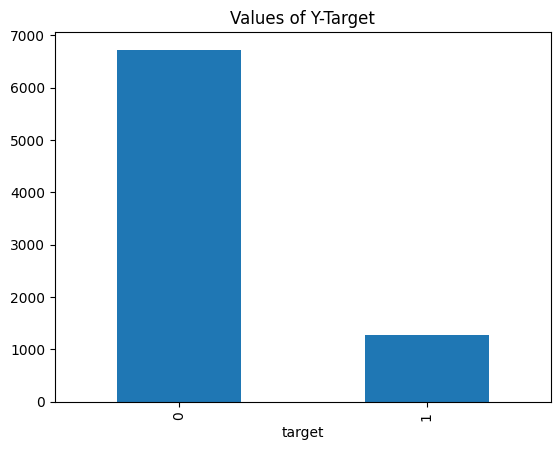

In [3]:
# Plot the number of observations in each class (0 = stay, 1 = leave)
# This helps us check whether the dataset is balanced or imbalanced
y.value_counts().plot(kind='bar')

# Add a title so the chart is easier to interpret
plt.title('Values of Y-Target')

# Display the chart
plt.show()


## Train/Test Split


Now we will split the data into a training set and a test set. The training set will be used to train the model, and the test set will be used to evaluate the model's performance on unseen data. Remember:

- stratify the split to maintain the class distribution in both sets. Since the dataset is imbalanced
- do not toouch the test set in any way until the final evaluation step. The test set should only be used once to evaluate the final model performance.

In [4]:
# Split the dataset into training and testing sets
# The model learns patterns from the training data and is evaluated on the test data
X_train, X_test, y_train, y_test = train_test_split(
                     X, y, 
    test_size=0.3, # 30% of the data is reserved for testing the model
    random_state=42, # ensures the split is reproducible
    stratify=y # keeps the class distribution (0/1) the same in both sets
)


## Model Training


Let fit the Logistic Regression, Decision Tree, and Random Forest models

In [5]:
# Create a logistic regression model
# Logistic regression estimates the probability that an observation belongs to class 1
model_lr = LogisticRegression(random_state=42)

# Train the model using the training data
model_lr.fit(X_train, y_train)


# Create a decision tree model
# A decision tree learns a series of decision rules to classify observations
model_dt = DecisionTreeClassifier(random_state=42)


# Train the decision tree on the training data
model_dt.fit(X_train, y_train)


# Create a random forest model
# A random forest combines many decision trees to improve prediction stability
model_rf = RandomForestClassifier(random_state=42)

# Train the random forest using the training data
model_rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In the next section we jump straight to cross validation as the single train/test split is not enough to evaluate the models. (remeber, our  model might get lucky with the train/test split so we do k-folds cross validation to get a better estimate of the model performance)

## Cross-Validation 


### we use cross validation with k=5 folds and we evaluate the precision metric across the folds

In [6]:
import seaborn as sns
# Perform 5-fold cross-validation on the logistic regression model
# The training data is split into 5 parts; the model trains on 4 parts and validates on the remaining part, repeating this process 5 times
cv_scores_lr = cross_val_score(model_lr, X_train, y_train, cv=5, scoring='precision')

# Convert the cross-validation results into a DataFrame for easier inspection
cv_results_lr = pd.DataFrame(cv_scores_lr)

# Display summary statistics of the validation precision scores across the 5 folds
# This helps us understand the average performance and variability of the model
print(cv_results_lr.describe())

              0
count  5.000000
mean   0.862295
std    0.039853
min    0.822222
25%    0.822222
50%    0.871795
75%    0.880952
max    0.914286


In [7]:
# Perform 5-fold cross-validation on the decision tree model
# The training data is split into 5 folds; each fold is used once as validation while the model trains on the remaining folds
cv_scores_dt = cross_val_score(model_dt, X_train, y_train, cv=5, scoring='precision')

# Convert the cross-validation results into a DataFrame for easier inspection
cv_results_dt = pd.DataFrame(cv_scores_dt)

# Display summary statistics of the validation precision scores across the 5 folds
# This helps us understand the average performance and variability of the model
print(cv_results_dt.describe())


              0
count  5.000000
mean   0.672552
std    0.031547
min    0.628272
25%    0.653179
50%    0.680628
75%    0.696133
max    0.704545


In [8]:
# Perform 5-fold cross-validation on the random forest model
# The training data is split into 5 folds; the model trains on 4 folds and validates on the remaining fold, repeating this process 5 times
cv_scores_rf = cross_val_score(model_rf, X_train, y_train, cv=5, scoring='precision')

# Convert the cross-validation results into a DataFrame for easier inspection
cv_results_rf = pd.DataFrame(cv_scores_rf)

# Display summary statistics of the validation precision scores across the 5 folds
# This helps us understand the average performance and variability of the model
print(cv_results_rf.describe())


              0
count  5.000000
mean   0.966562
std    0.010548
min    0.953125
25%    0.957265
50%    0.972222
75%    0.974790
max    0.975410


### Rather than try to manually cross reference the precision scores across the different models, we can use boxplots to visualise the distribution of precision scores across the different models.

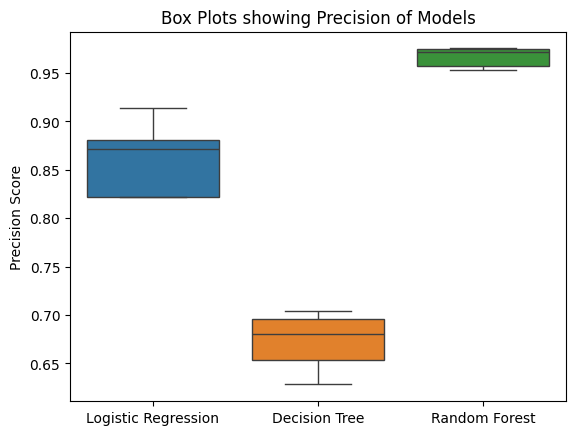

In [9]:
# Combine the cross-validation precision scores from each model into one DataFrame
# This allows us to easily compare model performance side-by-side
cv_results = pd.DataFrame({
    'Logistic Regression': cv_results_lr[0],  # precision scores from logistic regression
    'Decision Tree': cv_results_dt[0],        # precision scores from decision tree
    'Random Forest': cv_results_rf[0]         # precision scores from random forest
})

# Create a boxplot to visualise the distribution of precision scores across the 5 folds for each model
# The box shows the typical range of performance, while the whiskers show variability
sns.boxplot(cv_results)

# Add a title to describe what the chart shows
plt.title('Box Plots showing Precision of Models')

# Label the y-axis so we know the metric being evaluated
plt.ylabel('Precision Score')

# Display the plot
plt.show()

Based on intital fits, the decision decision tree appears to have a much harder time being consistent in its precision scores. But remember, the intial fits are just that - initial. We will need to do hyperparameter tuning to see if we can improve the performance of our models

# Hyperparameter Tuning

In [10]:
# Define the hyperparameter values we want to test for logistic regression
# Grid search will try every combination of these values
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],   # controls regularisation strength (smaller values = stronger regularisation)
    'penalty': ['l1', 'l2'],        # type of regularisation applied to the model
    'solver': ['liblinear']         # optimisation algorithm that supports both L1 and L2 penalties
}

# Create the GridSearchCV object
# This will test each parameter combination using 5-fold cross-validation
grid_lr = GridSearchCV(
                model_lr,          # base model to tune
                param_grid=param_grid,      # parameter combinations to evaluate
                cv=5,        # number of cross-validation folds
                scoring='precision',         # evaluation metric used to select the best model
                verbose=1
)

# Run the grid search on the training data
# The model is trained and evaluated many times across the parameter combinations
grid_lr.fit(X_train, y_train)

# Retrieve the model with the best performing hyperparameters
best_model_lr = grid_lr.best_estimator_

# Display the best parameter combination found during the search
print(f"Best params: {grid_lr.best_params_}. Score: {grid_lr.best_score_}")



Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best params: {'C': 0.01, 'penalty': 'l2', 'solver': 'liblinear'}. Score: 0.8806582633053222


In [11]:
# Define the hyperparameter values we want to test for the decision tree
# Grid search will evaluate every combination of these parameters
param_grid = {
    'max_depth': [None, 5, 10, 20],       # limits how deep the tree can grow (controls model complexity)
    'min_samples_split': [2, 5, 10],      # minimum number of samples required to split a node
    'min_samples_leaf': [1, 2, 4]         # minimum number of samples required in a leaf node
}
 
# Create the GridSearchCV object for the decision tree
# Each parameter combination will be evaluated using 5-fold cross-validation
grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),  # base model to tune
    param_grid,                               # parameter combinations to test
    cv=5,                                     # number of cross-validation folds
    scoring='precision'                       # metric used to select the best model
)
 
# Run the grid search on the training data
# The model is trained and evaluated multiple times across all parameter combinations
grid_dt.fit(X_train, y_train)
 
# Retrieve the decision tree model with the best performing hyperparameters
best_model_dt = grid_dt.best_estimator_
 
# Display the best parameter combination found during the search
print('Best parameters:', grid_dt.best_params_)
 
# Display the best average cross-validation precision achieved
print('Best CV Precision (Decision Tree):', grid_dt.best_score_)


Best parameters: {'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 2}
Best CV Precision (Decision Tree): 0.8888170926371928


In [12]:
# Define the hyperparameter values to test for the random forest model
# Grid search will evaluate each combination to find the best-performing settings

# xxx
# param_grid = {
#     'n_estimators': [150],            # number of trees in the forest
#     'max_depth': [None, 10],          # maximum depth of each tree (controls complexity)
#     'min_samples_split': [2, 5],      # minimum number of samples required to split a node
#     'min_samples_leaf': [1, 2]        # minimum number of samples required in a leaf node
# }

# # Create the GridSearchCV object for the random forest
# # Each parameter combination will be evaluated using 5-fold cross-validation
# grid_rf = GridSearchCV(
#                    model_rf,             # base model to tune
#                    param_grid,          # hyperparameter combinations to test
#                    cv=5,             # number of cross-validation folds
#                    scoring='precision'             # evaluation metric used to select the best model
# )

# # Run the grid search on the training data
# # The model is trained and evaluated multiple times using different parameter combinations
# grid_rf.fit(X_train, y_train)

# # Retrieve the random forest model with the best-performing hyperparameters
# best_model_rf = grid_rf.best_estimator_

# # Display the best parameter combination identified during the search
# print(f"Best params: {grid_rf.best_params_}")

# # Display the best average cross-validation precision score achieved
# print(f"Best Score: {grid_rf.best_score_}")

In [13]:
# # Decision Tree
# best_index_dt = grid_dt.best_index_

# dt_scores = [
#     grid_dt.cv_results_['split0_test_score'][best_index_dt],
#     grid_dt.cv_results_['split1_test_score'][best_index_dt],
#     grid_dt.cv_results_['split2_test_score'][best_index_dt],
#     grid_dt.cv_results_['split3_test_score'][best_index_dt],
#     grid_dt.cv_results_['split4_test_score'][best_index_dt],
# ]


# # Random Forest
# best_index_rf = grid_rf.best_index_

# rf_scores = [
#     grid_rf.cv_results_['split0_test_score'][best_index_rf],
#     grid_rf.cv_results_['split1_test_score'][best_index_rf],
#     grid_rf.cv_results_['split2_test_score'][best_index_rf],
#     grid_rf.cv_results_['split3_test_score'][best_index_rf],
#     grid_rf.cv_results_['split4_test_score'][best_index_rf],
# ]


# # Logistic Regression
# best_index_lr = grid_lr.best_index_

# lr_scores = [
#     grid_lr.cv_results_['split0_test_score'][best_index_lr],
#     grid_lr.cv_results_['split1_test_score'][best_index_lr],
#     grid_lr.cv_results_['split2_test_score'][best_index_lr],
#     grid_lr.cv_results_['split3_test_score'][best_index_lr],
#     grid_lr.cv_results_['split4_test_score'][best_index_lr],
# ]

In [14]:
# import matplotlib.pyplot as plt

# # Create a boxplot to compare the cross-validation precision scores
# # for the best tuned versions of each model
# plt.boxplot([dt_scores, rf_scores, lr_scores])

# # Label each box with the corresponding model name
# plt.xticks([1, 2, 3], ['Decision Tree', 'Random Forest', 'Logistic Regression'])

# # Label the y-axis to indicate the evaluation metric being compared
# plt.ylabel('CV Precision')

# # Add a title to explain what the chart represents
# plt.title('Cross-Validated Precision Distribution (Best Tuned Models)')

# # Display the plot
# plt.show()

---
##  Model Evaluation For Classification
---

how do we know that are model has learned anything at all? a great way is to create a baseline model model that just makes random prediction and see how our model performs against that baseline.

In [15]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import confusion_matrix, precision_score, recall_score
from sklearn.metrics import average_precision_score, roc_auc_score

# Create a dummy classifier to act as a baseline model
# "stratified" means predictions are made randomly but follow the same class proportions as the training data
dummy = DummyClassifier(strategy="stratified", random_state=42)
 
# Fit the dummy model on the training data
# The model does not learn patterns, it simply records the class distribution
dummy.fit(X_train, y_train)
 
# Generate class predictions on the test set
# These are random predictions based on the observed class proportions
y_dummy_pred = dummy.predict(X_test)


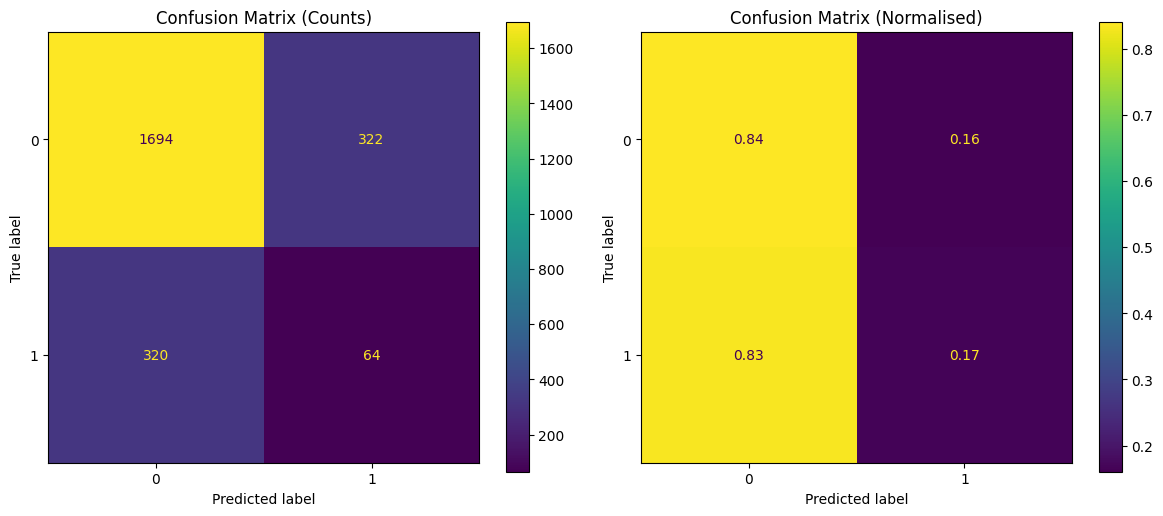

In [16]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Raw counts
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_dummy_pred,
    ax=axes[0],
    values_format="d"
)
axes[0].set_title("Confusion Matrix (Counts)")

# Normalised
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_dummy_pred,
    normalize="true",
    ax=axes[1],
    values_format=".2f"
)
axes[1].set_title("Confusion Matrix (Normalised)")

plt.tight_layout()
plt.show()

In [17]:
# Evaluate the dummy (random baseline) model using common classification metrics

# Accuracy shows the proportion of total predictions that were correct
# This metric can be misleading when classes are imbalanced
print("Dummy Accuracy:", accuracy_score(y_test, y_dummy_pred))
 
# Precision shows how many of the predicted positive cases were actually correct
# zero_division=0 prevents errors if the model predicts no positive cases
print("Dummy Precision:", precision_score(y_test, y_dummy_pred, zero_division=0))
 
# Recall shows how many of the actual positive cases were successfully identified
print("Dummy Recall:", recall_score(y_test, y_dummy_pred, zero_division=0))

Dummy Accuracy: 0.7325
Dummy Precision: 0.16580310880829016
Dummy Recall: 0.16666666666666666


# Policy Interpretation

Random guessing results show that:

when the model predicts a resident will leave, it is correct only about 17% of the time (precision ~17%).

Only ~17% of true leavers would be identified.

Most funding would be misdirected.

This is not a viable policy tool.

---
# Evaluating The Best Model
---

we import the best model from the previous section

In [18]:
# Select the final model to evaluate on the test set
# Here we choose the best-performing random forest model from the grid search
best_model = best_model_lr

In [19]:
# Generate predicted class labels for the test data
# The model assigns each observation to class 0 (stay) or class 1 (leave)
y_pred = best_model.predict(X_test)

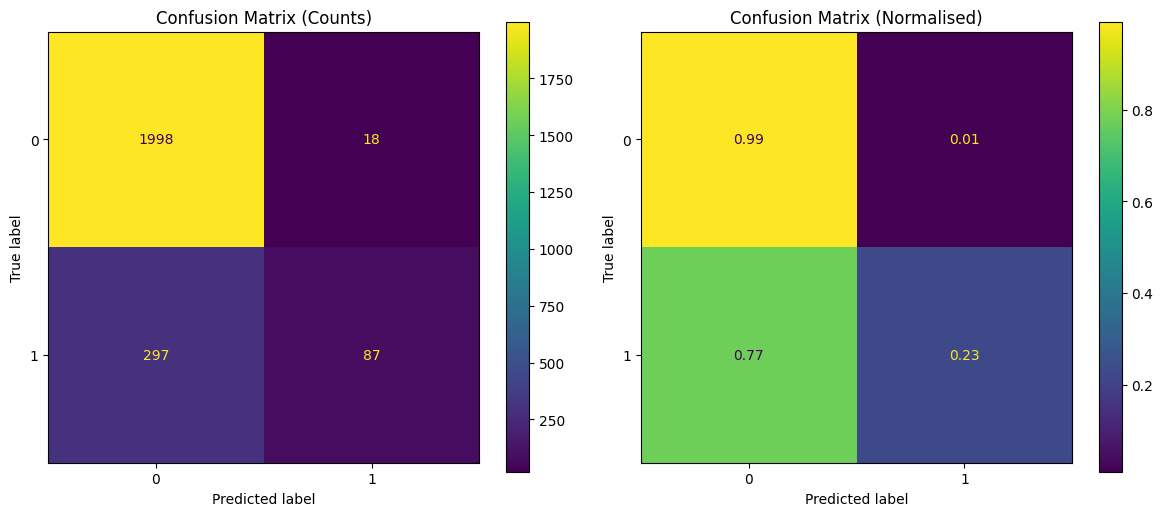

In [20]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Raw counts
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    ax=axes[0],
    values_format="d"
)
axes[0].set_title("Confusion Matrix (Counts)")

# Normalised
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    normalize="true",
    ax=axes[1],
    values_format=".2f"
)
axes[1].set_title("Confusion Matrix (Normalised)")

plt.tight_layout()
plt.show()

In [21]:
# Calculate precision for the model's predictions
# Precision tells us: of all the people the model flagged as at risk, how many actually leave
print('Precision:', precision_score(y_test, y_pred))
 
# Calculate recall for the model's predictions
# Recall tells us: of all the people who actually leave, how many the model successfully identified
print('Recall:', recall_score(y_test, y_pred))


Precision: 0.8285714285714286
Recall: 0.2265625



# Precision

When the model predicts that someone is at risk of leaving, it is correct about 96% of the time.

So the misallocation of financial resources is very low.

### Policy framing

The model results in very little wasted intervention spending.

# Recall

The model correctly identifies about 63% of the individuals who actually leave.

### policy framing

The model captures most at-risk individuals but does not detect all of them.

The remaining 37% missed may still leave without intervention.

### So the trade-off is clear

The model prioritises accuracy of intervention over identifying every possible leaver. As we'd hoped, the model is very good at targeting interventions to those who are truly at risk, but it does not capture every single case. This is a common and acceptable trade-off in many real-world applications, especially when resources are limited and the cost of false positives is high.


---
# Further Consideration: Adding Uncertainty Estimates To Our Predictions
---

As we mentioned in the Regression notebook, using a single value (point estimate) to evaluate model performance can be misleading. we use bootstrapping to measure the uncertainty in precision scores to get a better understanding of the model performance in the case the test set is slightly different than the one we have.

In [22]:
rng = np.random.default_rng(42)

n_boot = 5000
n = len(y_test)

boot_precisions = np.empty(n_boot)

# convert to numpy arrays to allow fancy indexing reliably
y_true = np.asarray(y_test)
y_hat = np.asarray(y_pred)

for b in range(n_boot):
    idx = rng.integers(0, n, size=n)  # sample indices with replacement
    boot_precisions[b] = precision_score(y_true[idx], y_hat[idx], zero_division=0)

ci_low, ci_high = np.percentile(boot_precisions, [2.5, 97.5])

print(f"Precision (bootstrap 95% CI): [{ci_low:.4f}, {ci_high:.4f}]")

Precision (bootstrap 95% CI): [0.7521, 0.8962]


In simple terms, this means:

If we tested the model on another similar dataset, the precision might change a little.
The confidence interval shows how much it could realistically change.

So instead of saying:
The model is correct exactly 96% of the time,

Our test set is just one sample of data.

If you collected another similar dataset:
- Precision might be 93%
- or 96%
- or 98%

The interval shows the likely range.

we say:
It is probably between 93% and 98% correct, depending on the sample we happened to test it on.



---
# Further Considerations - PR Curve
---

At a threshold of 0.5 default threshold. the model achieves precision of 0.96, meaning only 4% of funded interventions would be misallocated. This reflects strong fiscal discipline. However, recall is 0.63, implying that nearly 40% of at-risk individuals would receive no preventative support, with potential long-term social and economic costs.

if we are asked can we increase the recall while maintaining acceptable precision levels, we can get the precision-recall curve and see if there are other thresholds that would give us a better balance between precision and recall.

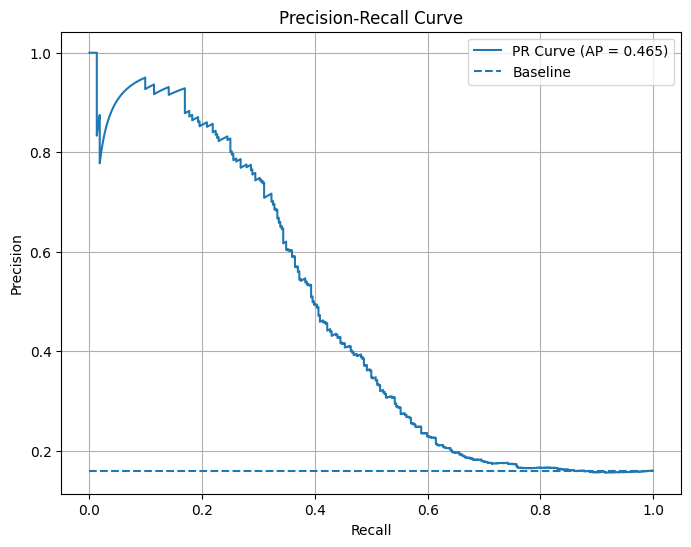

In [23]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import numpy as np

y_proba = best_model.predict_proba(X_test)[:, 1]

precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_proba)
pr_auc = average_precision_score(y_test, y_proba)

plt.figure(figsize=(8,6))
plt.plot(recall_vals, precision_vals, label=f"PR Curve (AP = {pr_auc:.3f})")

# Baseline precision = positive rate
baseline = np.mean(y_test)
plt.hlines(baseline, 0, 1, linestyles="dashed", label="Baseline")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid(True)
plt.show()

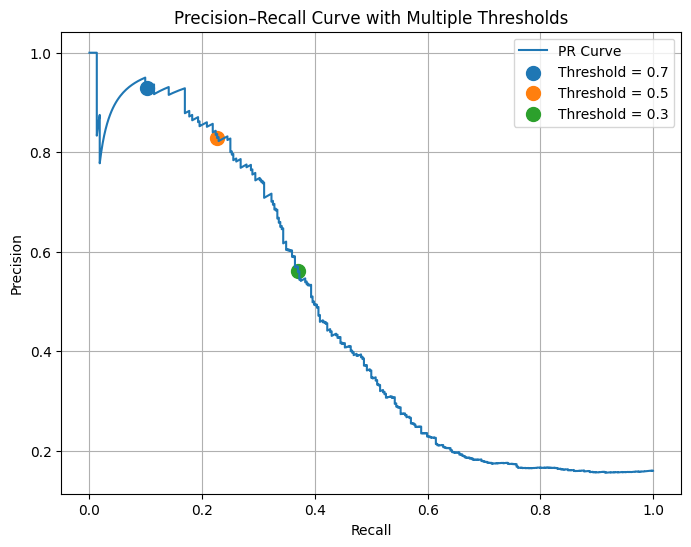

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, precision_score, recall_score

# Compute PR curve
precision_vals, recall_vals, thresholds = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(8,6))
plt.plot(recall_vals, precision_vals, label="PR Curve")

# Choose several thresholds to demonstrate movement
threshold_list = [0.7, 0.5, 0.3]

for t in threshold_list:
    y_pred_t = (y_proba >= t).astype(int)
    prec_t = precision_score(y_test, y_pred_t, zero_division=0)
    rec_t = recall_score(y_test, y_pred_t, zero_division=0)

    plt.scatter(rec_t, prec_t, s=100, label=f"Threshold = {t}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve with Multiple Thresholds")
plt.legend()
plt.grid(True)
plt.show()

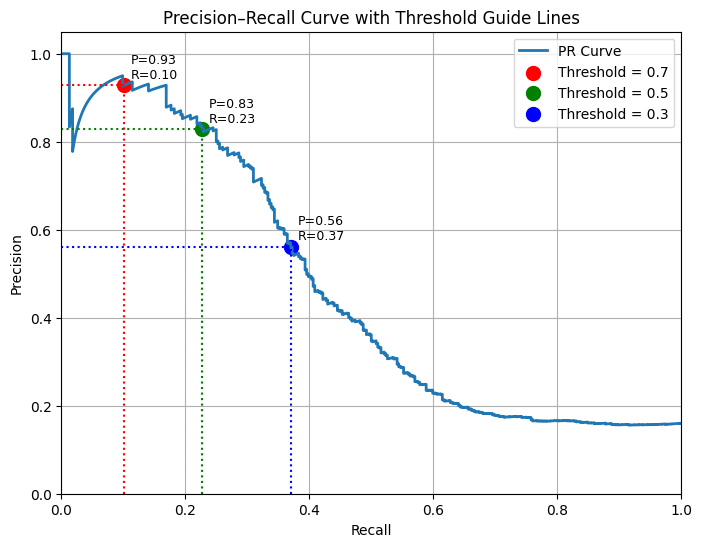

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, precision_score, recall_score

# Compute PR curve
precision_vals, recall_vals, thresholds = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(8,6))
plt.plot(recall_vals, precision_vals, label="PR Curve", linewidth=2)

# Choose several thresholds to demonstrate movement
threshold_list = [0.7, 0.5, 0.3]
colors = ["red", "green", "blue"]

for t, c in zip(threshold_list, colors):
    y_pred_t = (y_proba >= t).astype(int)
    prec_t = precision_score(y_test, y_pred_t, zero_division=0)
    rec_t = recall_score(y_test, y_pred_t, zero_division=0)

    # Plot the point
    plt.scatter(rec_t, prec_t, color=c, s=100, label=f"Threshold = {t}")

    # Vertical line (recall)
    plt.vlines(rec_t, 0, prec_t, linestyles="dotted", colors=c)

    # Horizontal line (precision)
    plt.hlines(prec_t, 0, rec_t, linestyles="dotted", colors=c)

    # Annotate values
    plt.annotate(
        f"P={prec_t:.2f}\nR={rec_t:.2f}",
        (rec_t, prec_t),
        textcoords="offset points",
        xytext=(5,5),
        fontsize=9
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve with Threshold Guide Lines")
plt.xlim(0,1)
plt.ylim(0,1.05)
plt.legend()
plt.grid(True)

plt.show()

In [26]:
from sklearn.metrics import precision_recall_curve
import numpy as np

precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)

target_precision = 0.96

valid = precisions[:-1] >= target_precision

best_idx = np.argmax(recalls[:-1][valid])
chosen_threshold = thresholds[valid][best_idx]

print("Chosen threshold:", chosen_threshold)
print("Precision at chosen threshold:", precisions[:-1][valid][best_idx])
print("Recall at chosen threshold:", recalls[:-1][valid][best_idx])

Chosen threshold: 0.9038039529954386
Precision at chosen threshold: 1.0
Recall at chosen threshold: 0.013020833333333334
